In [ ]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from numpy import pi
from qiskit.qasm3 import dumps as qasm3_dumps
from qiskit.qasm import dumps as qasm2_dumps

In [2]:
qreg_q = QuantumRegister(3, 'q')
creg_c = ClassicalRegister(3, 'c')
circuit = QuantumCircuit(qreg_q, creg_c)

In [3]:
circuit.h(qreg_q[2])
circuit.cx(qreg_q[2], qreg_q[1])
circuit.cx(qreg_q[2], qreg_q[0])
circuit.measure(qreg_q[0], creg_c[0])
circuit.measure(qreg_q[1], creg_c[1])
circuit.measure(qreg_q[2], creg_c[2])

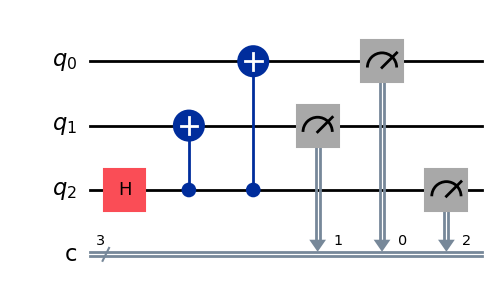

In [4]:
circuit.draw(output="mpl")

In [5]:
print(qasm3_dumps(circuit))

OPENQASM 3.0;
include "stdgates.inc";
bit[3] c;
qubit[3] q;
h q[2];
cx q[2], q[1];
cx q[2], q[0];
c[0] = measure q[0];
c[1] = measure q[1];
c[2] = measure q[2];



In [6]:
print(qasm2_dumps(circuit))

OPENQASM 2.0;
include "qelib1.inc";
qreg q[3];
creg c[3];
h q[2];
cx q[2],q[1];
cx q[2],q[0];
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];


In [ ]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import SamplerV2 as AerSampler

In [ ]:
pass_manager = generate_preset_pass_manager(
    optimization_level=2, backend=AerSimulator())
isa_circuit = pass_manager.run(circuit)
noise_model = NoiseModel()

sampler = AerSampler(options={"backend_options": {"noise_model": noise_model}})
job = sampler.run([isa_circuit], shots=1024)
result = job.result()[0]
print(result.data.c.get_counts())

{'000': 498, '111': 526}


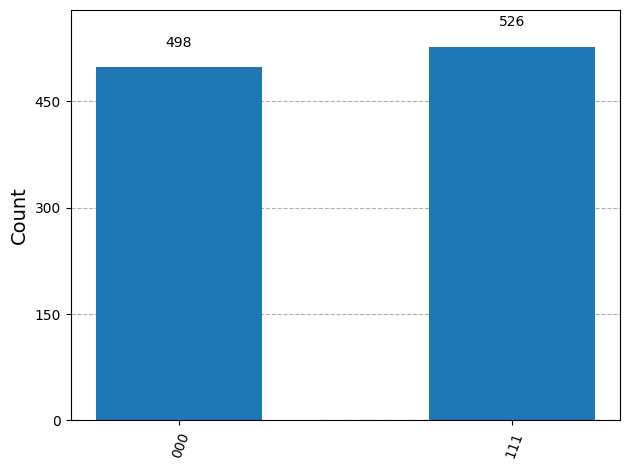

In [18]:
from qiskit.visualization import plot_histogram
plot_histogram(result.data.c.get_counts())

In [31]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

service = QiskitRuntimeService()

In [32]:
service.backends()

[<IBMBackend('ibm_fez')>,
 <IBMBackend('ibm_marrakesh')>,
 <IBMBackend('ibm_torino')>]

In [33]:
backend = service.least_busy(operational=True, min_num_qubits=5)
print(backend)

<IBMBackend('ibm_marrakesh')>


In [34]:
backend.configuration()

In [35]:

pass_manager = generate_preset_pass_manager(
    optimization_level=2, backend=backend)
isa_circuit = pass_manager.run(circuit)
sampler = Sampler(backend)
job = sampler.run([isa_circuit])
result = job.result()

In [44]:
sampler_result = result[0]
counts = sampler_result.data.c.get_counts()
counts

{'111': 1882,
 '000': 2111,
 '101': 19,
 '011': 33,
 '001': 13,
 '010': 12,
 '110': 25,
 '100': 1}

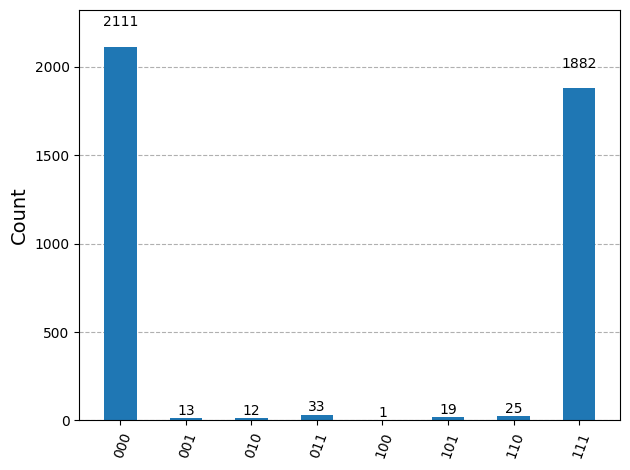

In [45]:

plot_histogram(counts)